# Modelo XGBoost
---

### Configuración de ambiente

In [13]:
import yfinance as yf
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import pandas_ta as ta

import xgboost as xgb
from sklearn.preprocessing import LabelEncoder

import lightgbm as lgb

import warnings
warnings.filterwarnings("ignore")

## Funciones
---

In [4]:
def obtener_datos_btc(fecha_inicio, fecha_fin):
    """Extrae datos de Yahoo Finance y calcula features básicas."""
    print(f"Descargando datos de BTC-USD desde {fecha_inicio}...")
    btc = yf.download("BTC-USD", start=fecha_inicio, end=fecha_fin)
    
    if isinstance(btc.columns, pd.MultiIndex):
        btc.columns = btc.columns.get_level_values(0)

    df = btc[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
    df.dropna(inplace=True)
    
    # Feature básica: Retornos logarítmicos
    df['Retorno_Log'] = np.log(df['Close'] / df['Close'].shift(1))
    return df

def etiquetar_puntos_criticos(df, ventana):
    """
    Etiqueta máximos (1) y mínimos (-1) locales.
    Un punto es máximo/mínimo si es el extremo en +/- 'ventana' periodos.
    """
    # Creamos una copia para no alterar el original durante el cálculo
    temp_df = df.copy()
    
    # Buscamos el máximo y mínimo en la ventana centrada
    # center=True permite ver 'ventana' hacia atrás y 'ventana' hacia adelante
    temp_df['Max_Local'] = temp_df['High'].rolling(window=ventana*2+1, center=True).max()
    temp_df['Min_Local'] = temp_df['Low'].rolling(window=ventana*2+1, center=True).min()
    
    # Inicializamos la columna Target en 0 (Neutral)
    temp_df['Target'] = 0
    
    # Si el High actual es igual al Max_Local de la ventana, es un máximo (1)
    temp_df.loc[temp_df['High'] == temp_df['Max_Local'], 'Target'] = 1
    
    # Si el Low actual es igual al Min_Local de la ventana, es un mínimo (-1)
    temp_df.loc[temp_df['Low'] == temp_df['Min_Local'], 'Target'] = -1
    
    # Limpiamos columnas auxiliares
    temp_df.drop(columns=['Max_Local', 'Min_Local'], inplace=True)
    
    return temp_df

def agregar_indicadores_avanzados(
    df,
    rsi_len=14,
    bb_len=20,
    stoch_k=9, stoch_d=6,
    stochrsi_len=14,
    macd_fast=12, macd_slow=26, macd_sig=9,
    adx_len=14,
    willr_len=14,
    cci_len=14,
    atr_len=14,
    roc_len=10,
    eri_len=13,
    uo_fast=7, uo_med=14, uo_slow=28,
    vol_ma_len=20 # Media móvil para nuestro volumen relativo
):
    """
    Calcula indicadores técnicos avanzados usando pandas_ta.
    Todos los periodos son parametrizables para facilitar optimizaciones futuras.
    """
    temp_df = df.copy()
    
    # Aseguramos que el índice sea datetime
    if not isinstance(temp_df.index, pd.DatetimeIndex):
         temp_df.index = pd.to_datetime(temp_df.index)

    # 1. RSI
    temp_df.ta.rsi(length=rsi_len, append=True)
    
    # 2. Bandas de Bollinger
    temp_df.ta.bbands(length=bb_len, append=True)
    
    # Retornos y Volumen Relativo manuales
    temp_df['Retorno_1d'] = temp_df['Close'].pct_change()
    temp_df['Volumen_Relativo'] = temp_df['Volume'] / temp_df['Volume'].rolling(window=vol_ma_len).mean()
    
    # 3. STOCH
    temp_df.ta.stoch(k=stoch_k, d=stoch_d, append=True)
    
    # 4. STOCHRSI
    temp_df.ta.stochrsi(length=stochrsi_len, append=True)
    
    # 5. MACD (Añadí macd_sig=9 porque pandas_ta lo usa por defecto para el histograma)
    temp_df.ta.macd(fast=macd_fast, slow=macd_slow, signal=macd_sig, append=True)
    
    # 6. ADX
    temp_df.ta.adx(length=adx_len, append=True)
    
    # 7. Williams %R
    temp_df.ta.willr(length=willr_len, append=True)
    
    # 8. CCI
    temp_df.ta.cci(length=cci_len, append=True)
    
    # 9. ATR
    temp_df.ta.atr(length=atr_len, append=True)
    
    # 10. ROC
    temp_df.ta.roc(length=roc_len, append=True)
    
    # 11. Bull/Bear Power (Elder-Ray Index)
    temp_df.ta.eri(length=eri_len, append=True)
    
    # 12. Ultimate Oscillator
    temp_df.ta.uo(fast=uo_fast, medium=uo_med, slow=uo_slow, append=True)
    
    # Limpiamos las filas iniciales que quedan con NaN por los periodos de cálculo
    temp_df.dropna(inplace=True)
    
    return temp_df

def agregar_contexto_macro(df_btc):
    """
    Descarga datos del S&P 500, DXY y Oro, y los alinea con el dataset de Bitcoin,
    manejando los cierres de mercado de fin de semana.
    """
    print("Iniciando descarga de datos macroeconómicos...")
    temp_df = df_btc.copy()
    
    # Extraemos las fechas de nuestro dataset actual para descargar exactamente el mismo periodo
    fecha_inicio = temp_df.index.min()
    # Sumamos un día a la fecha final para asegurar que yfinance incluya el último día
    fecha_fin = temp_df.index.max() + pd.Timedelta(days=1) 
    
    # Diccionario con los nombres y sus tickers en Yahoo Finance
    activos_macro = {
        "SP500": "^GSPC", 
        "DXY": "DX-Y.NYB", 
        "Oro": "GC=F"
    }
    
    # Creamos un DataFrame vacío pero con las mismas fechas que Bitcoin (los 365 días del año)
    df_macro = pd.DataFrame(index=temp_df.index)
    
    for nombre, ticker in activos_macro.items():
        print(f"-> Descargando {nombre} ({ticker})...")
        data = yf.download(ticker, start=fecha_inicio, end=fecha_fin, progress=False)
        
        # Limpieza del MultiIndex de yfinance (como hicimos con BTC)
        if isinstance(data.columns, pd.MultiIndex):
            data.columns = data.columns.get_level_values(0)
            
        # Guardamos solo el precio de cierre
        df_macro[f'{nombre}_Close'] = data['Close']
    
    # --- EL TRUCO DEL FIN DE SEMANA (Forward Fill) ---
    # Rellenamos los NaN de los fines de semana con el último dato válido (Viernes)
    df_macro = df_macro.ffill()
    
    # Rellenamos hacia atrás (Back Fill) por si el día 1 del dataset fue fin de semana
    df_macro = df_macro.bfill()
    
    # Calculamos los retornos diarios de los activos macro (Esto le sirve más al modelo que el precio crudo)
    for nombre in activos_macro.keys():
        df_macro[f'{nombre}_Retorno'] = df_macro[f'{nombre}_Close'].pct_change()
        
    # Unimos la macroeconomía a nuestro dataset del Proyecto Apex
    # Como ambos comparten el mismo índice (fechas), la unión es perfecta
    temp_df = temp_df.join(df_macro)
    
    # Eliminamos la primera fila que quedará con NaN por calcular los retornos
    temp_df.dropna(inplace=True)
    
    print("\n¡Contexto macro agregado exitosamente!")
    return temp_df



In [5]:
# Función backtester
def backtest_apex(
        df_test, 
        predicciones, 
        capital_inicial=1000.0, 
        tamaño_posicion=0.10, 
        stop_loss=0.05):
    
    """
    Simula una estrategia de trading basada en las predicciones del modelo.
    capital_inicial: Capital base para arrancar (ej. 1000 USD).
    tamaño_posicion: Porcentaje del capital total a invertir en cada compra (ej. 10%).
    stop_loss: Porcentaje máximo de pérdida tolerada por operación (ej. 5%).
    """
    df_sim = df_test.copy()
    df_sim['Señal'] = predicciones
    
    capital_actual = capital_inicial
    posicion_abierta = False
    precio_compra = 0.0
    cantidad_btc = 0.0
    
    historial_trades = []
    evolucion_capital = []

    for fecha, fila in df_sim.iterrows():
        precio_actual = fila['Close']
        señal = fila['Señal']
        
        # Revisar Stop Loss si tenemos una posición abierta
        if posicion_abierta:
            caida_desde_compra = (precio_actual - precio_compra) / precio_compra
            if caida_desde_compra <= -stop_loss:
                # Se ejecutó el Stop Loss
                capital_actual += cantidad_btc * precio_actual
                historial_trades.append({'Fecha': fecha, 'Tipo': 'Venta (Stop Loss)', 'Precio': precio_actual, 'Capital': capital_actual})
                posicion_abierta = False
                cantidad_btc = 0.0

        # Lógica de Compra
        if señal == -1 and not posicion_abierta:
            monto_invertir = capital_actual * tamaño_posicion
            cantidad_btc = monto_invertir / precio_actual
            capital_actual -= monto_invertir
            precio_compra = precio_actual
            posicion_abierta = True
            historial_trades.append(
                {
                    'Fecha': fecha, 
                    'Tipo': 'Compra', 
                    'Precio': precio_actual, 
                    'Capital': capital_actual + (cantidad_btc * precio_actual)
                    })
            
        # Lógica de Venta (Toma de Ganancias)
        elif señal == 1 and posicion_abierta:
            capital_actual += cantidad_btc * precio_actual
            historial_trades.append(
                {
                    'Fecha': fecha, 
                    'Tipo': 'Venta (Take Profit)', 
                    'Precio': precio_actual, 
                    'Capital': capital_actual
                    })
            posicion_abierta = False
            cantidad_btc = 0.0
            
        # Registrar el valor total del portafolio (Efectivo + Valor en BTC)
        valor_portafolio = capital_actual + (cantidad_btc * precio_actual if posicion_abierta else 0)
        evolucion_capital.append(valor_portafolio)

    df_sim['Valor_Portafolio'] = evolucion_capital
    
    # Calcular métricas finales
    retorno_total = ((df_sim['Valor_Portafolio'].iloc[-1] - capital_inicial) / capital_inicial) * 100
    trades_df = pd.DataFrame(historial_trades)
    
    print(f"--- RESULTADOS DEL BACKTEST ---")
    print(f"Capital Inicial: ${capital_inicial:.2f} USD")
    print(f"Capital Final: ${df_sim['Valor_Portafolio'].iloc[-1]:.2f} USD")
    print(f"Retorno Total: {retorno_total:.2f}%")
    print(f"Total de operaciones cerradas: {len(trades_df[trades_df['Tipo'].str.contains('Venta')]) if not trades_df.empty else 0}")
    
    # Gráfica de la evolución del capital
    plt.figure(figsize=(10, 5))
    plt.plot(df_sim.index, df_sim['Valor_Portafolio'], color='blue', label='Curva de Capital')
    plt.title('Evolución del Portafolio de Trading')
    plt.ylabel('Valor en USD')
    plt.xlabel('Fecha')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
    
    return df_sim, trades_df

## Carga de datos
---


In [6]:
# --- EJECUCIÓN DEL PROYECTO APEX ---

# 1. Definimos parámetros
VENTANA_T = 5  # Esto buscará el máximo/mínimo en un rango de 7 velas (3 atrás, la actual, 3 adelante)

# 2. Obtenemos datos
df_apex = obtener_datos_btc(fecha_inicio="2024-01-01", fecha_fin="2026-01-01")

# 3. Aplicamos el etiquetado con la ventana parametrizada
df_apex = etiquetar_puntos_criticos(df_apex, ventana=VENTANA_T)

# 4. Resultados
print(f"\nEtiquetado completado con ventana t={VENTANA_T}")
print(df_apex['Target'].value_counts(dropna=False, normalize=True)) # Ver cuántos puntos encontramos
print("\nMuestra de puntos detectados (Target != 0):")
print(df_apex[df_apex['Target'] != 0].head(10))

Descargando datos de BTC-USD desde 2024-01-01...


[*********************100%***********************]  1 of 1 completed


Etiquetado completado con ventana t=5
Target
 0    0.874145
 1    0.062927
-1    0.062927
Name: proportion, dtype: float64

Muestra de puntos detectados (Target != 0):
Price               Open          High           Low         Close  \
Date                                                                 
2024-01-11  46656.074219  48969.371094  45678.644531  46368.585938   
2024-01-23  39518.714844  40127.351562  38521.894531  39845.550781   
2024-01-30  43300.226562  43838.945312  42711.371094  42952.609375   
2024-02-20  51777.726562  52945.050781  50792.312500  52284.875000   
2024-02-23  51283.906250  51497.933594  50561.777344  50731.949219   
2024-03-05  68341.054688  69170.625000  59323.910156  63801.199219   
2024-03-14  73079.375000  73750.070312  68563.023438  71396.593750   
2024-03-20  61930.156250  68115.257812  60807.785156  67913.671875   
2024-03-27  69991.898438  71727.687500  68381.929688  69455.343750   
2024-04-03  65446.671875  66914.320312  64559.898438  65980.8

## Indicadores técnicos (features)
---

In [7]:
# Aplicamos la función a nuestro dataset
# (Asumiendo que 'df_apex' ya tiene la columna 'Target' del paso anterior)
df_apex = agregar_indicadores_avanzados(df_apex)
print("Features agregadas con éxito. Tamaño del dataset:", df_apex.shape)

Features agregadas con éxito. Tamaño del dataset: (698, 34)


## Variables macroeconómicas
---

In [8]:
# --- EJECUCIÓN ---
# Aplicamos la función a nuestro dataset que ya tiene los indicadores técnicos
df_apex = agregar_contexto_macro(df_apex)

# Revisamos las nuevas columnas
nuevas_columnas = [col for col in df_apex.columns if 'SP500' in col or 'DXY' in col or 'Oro' in col]
print("\nNuevas variables macro disponibles para el modelo:")
print(nuevas_columnas)

Iniciando descarga de datos macroeconómicos...
-> Descargando SP500 (^GSPC)...
-> Descargando DXY (DX-Y.NYB)...
-> Descargando Oro (GC=F)...

¡Contexto macro agregado exitosamente!

Nuevas variables macro disponibles para el modelo:
['SP500_Close', 'DXY_Close', 'Oro_Close', 'SP500_Retorno', 'DXY_Retorno', 'Oro_Retorno']


## Entrenamiento del modelo XGBoost
---

In [9]:
# --- 1. CONFIGURACIÓN DE FEATURES ---
# Excluimos los precios crudos de BTC, el Target y los precios crudos macroeconómicos
columnas_excluir = [
    'Open', 'High', 'Low', 'Close', 'Volume', 'Target',
    'SP500_Close', 'DXY_Close', 'Oro_Close' # ¡Importante! Solo queremos sus retornos
    , 'Retorno_Log'
]

# Creamos la lista final de features (X)
features = [col for col in df_apex.columns if col not in columnas_excluir]

# --- 2. PREPARACIÓN DE DATOS (Train / Test) ---
X = df_apex[features]
y = df_apex['Target']

# División cronológica (80% Train, 20% Test)
split_idx = int(len(df_apex) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Entrenando con {len(features)} variables (Técnicas + Macro)...")
print(f"Días de entrenamiento: {len(X_train)} | Días de prueba: {len(X_test)}")

Entrenando con 30 variables (Técnicas + Macro)...
Días de entrenamiento: 557 | Días de prueba: 140


In [10]:
print("--- INICIANDO ENTRENAMIENTO XGBOOST ---")

# 1. Traducir las etiquetas (-1, 0, 1) a formato XGBoost (0, 1, 2)
le = LabelEncoder()
y_train_xgb = le.fit_transform(y_train)
y_test_xgb = le.transform(y_test)

# 2. Configurar el modelo XGBoost
# Nota: XGBoost es muy potente, por lo que usamos max_depth bajo para que no memorice el pasado
modelo_xgb = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,         # Árboles menos profundos para generalizar mejor
    learning_rate=0.05,  # Aprende despacio para no sobreajustarse
    random_state=42,
    n_jobs=-1
)

# 3. Entrenar
print("Entrenando modelo XGBoost...")
modelo_xgb.fit(X_train, y_train_xgb)

# 4. Obtener las probabilidades en los datos de prueba
probabilidades_xgb = modelo_xgb.predict_proba(X_test)

# 5. Aplicar nuestro "Umbral de Valentía" (25%)
UMBRAL_EXTREMO = 0.25
y_pred_xgb_ajustado = np.zeros(len(y_test))

# Encontramos qué columna de probabilidad corresponde al Mínimo y al Máximo
idx_minimo = np.where(le.classes_ == -1)[0][0]
idx_maximo = np.where(le.classes_ == 1)[0][0]

for i in range(len(probabilidades_xgb)):
    prob_min = probabilidades_xgb[i][idx_minimo]
    prob_max = probabilidades_xgb[i][idx_maximo]
    
    if prob_min >= UMBRAL_EXTREMO:
        y_pred_xgb_ajustado[i] = -1
    elif prob_max >= UMBRAL_EXTREMO:
        y_pred_xgb_ajustado[i] = 1


--- INICIANDO ENTRENAMIENTO XGBOOST ---
Entrenando modelo XGBoost...


In [11]:
# 5. Recuperamos la porción de "Test" pero del DataFrame original (que SÍ tiene 'Close')
split_idx = int(len(df_apex) * 0.8)
df_test_completo = df_apex.iloc[split_idx:].copy()

assert len(df_test_completo) == len(y_pred_xgb_ajustado), "Error: Las longitudes no coinciden"


--- SIMULACIÓN DE TRADING: XGBOOST ---
--- RESULTADOS DEL BACKTEST ---
Capital Inicial: $1000.00 USD
Capital Final: $988.63 USD
Retorno Total: -1.14%
Total de operaciones cerradas: 7


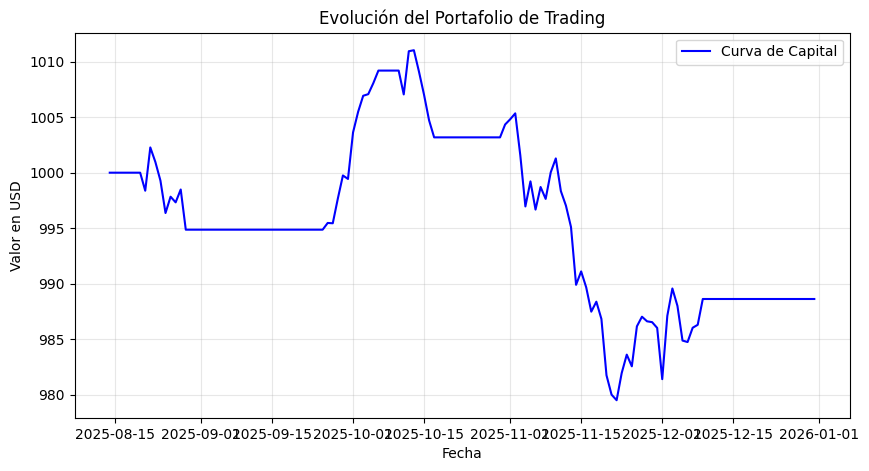

In [12]:
# 6. Ejecutar el Backtest con las nuevas predicciones
print("\n--- SIMULACIÓN DE TRADING: XGBOOST ---")
# Usamos df_test_completo que definimos en el paso anterior (el que incluye el 'Close')
df_sim_xgb, trades_xgb = backtest_apex(df_test_completo, y_pred_xgb_ajustado)

## Backtestester
---
Para este backtester, programaremos una lógica de operaciones en Spot.

La estrategia será:

- **Señal -1 (Mínimo)**: Compramos Bitcoin. Para no arriesgar la ruina total, invertiremos una fracción de nuestro capital por operación (ej. 10% del capital).

- **Señal 1 (Máximo)**: Vendemos la posición completa para asegurar ganancias.

- **Stop Loss (Gestión de Riesgo)**: Si el precio cae un cierto porcentaje desde nuestra compra, vendemos con pérdida para proteger el capital, sin esperar a que el modelo dé una señal de venta.

Simulación

In [17]:
# 1. Recuperamos la porción de "Test" pero del DataFrame original (que SÍ tiene 'Close')
split_idx = int(len(df_apex) * 0.8)
df_test_completo = df_apex.iloc[split_idx:].copy()


In [18]:
# 2. Nos aseguramos de que las predicciones ajustadas y el DataFrame tengan la misma longitud
assert len(df_test_completo) == len(y_pred_ajustado), "Error: Las longitudes no coinciden"

--- RESULTADOS DEL BACKTEST ---
Capital Inicial: $1000.00 USD
Capital Final: $985.08 USD
Retorno Total: -1.49%
Total de operaciones cerradas: 5


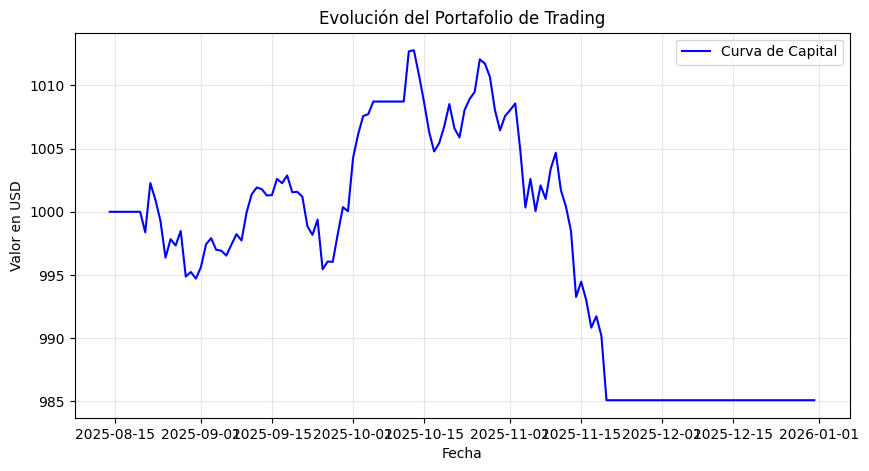

In [19]:
# 3. ¡Ahora sí ejecutamos el backtester!
# Le pasamos los datos completos y las predicciones que generamos con el Random Forest
df_simulacion, trades_rf = backtest_apex(df_test_completo, y_pred_ajustado)

In [20]:
# Opcional: ver las primeras 5 operaciones que hizo el bot
if not trades_rf.empty:
    print("\nÚltimas operaciones del bot:")
    print(trades_rf.tail())


Últimas operaciones del bot:
       Fecha               Tipo         Precio      Capital
5 2025-11-04  Venta (Stop Loss)  101590.523438  1000.337110
6 2025-11-04             Compra  101590.523438  1000.337110
7 2025-11-14  Venta (Stop Loss)   94397.789062   993.254599
8 2025-11-14             Compra   94397.789062   993.254599
9 2025-11-20  Venta (Stop Loss)   86631.898438   985.083321


Aunque seguimos en terreno negativo (-1.14%), XGBoost logró superar a Random Forest (-1.49%). Y lo más importante no es solo el número final, sino cómo llegó ahí.
Radiografía de XGBoost:

1. Más audaz (7 operaciones vs 5): XGBoost encontró más patrones que superaron nuestro umbral del 25% de seguridad. No se quedó "congelado" tanto tiempo como el Random Forest.

2. El "Jonrón" de Octubre: Si miras tu gráfica entre finales de septiembre y principios de octubre, la línea azul tiene una subida hermosa, casi vertical, superando los 1010 USD. XGBoost detectó una tendencia clara y la surfeó perfectamente.

3. El problema de soltar a tiempo: ¿Por qué perdimos esa ganancia? Porque en noviembre la volatilidad lo engañó. Entró en operaciones que rápidamente se fueron en contra, activando el Stop Loss varias veces seguidas (esas caídas en forma de "serrucho" a mediados de noviembre).

Terminar una simulación automática en 988.63 USD demuestra el reto real del trading algorítmico crudo. El objetivo de diseñar esta herramienta y optimizarla es precisamente darle la robustez necesaria para replicar escenarios de éxito reales, donde ese capital inicial de 1000 USD logre capturar los movimientos correctos y aumente a 1802.05 USD (consiguiendo esa excelente ganancia de 802.05 USD). Para llegar a ese nivel de rentabilidad, la clave estará en la gestión de la salida (Take Profit), no solo en la entrada.

## Entrenamiento de LightGBM
---

In [14]:
print("--- INICIANDO ENTRENAMIENTO LIGHTGBM ---")

# 1. Configurar el modelo LightGBM
# Usamos class_weight='balanced' para que preste atención a los extremos
modelo_lgb = lgb.LGBMClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1 # Para que no llene la consola de advertencias internas
)

# 2. Entrenar (usamos y_train_xgb que ya está codificado a 0, 1, 2)
print("Entrenando modelo LightGBM...")
modelo_lgb.fit(X_train, y_train_xgb)

# 3. Obtener las probabilidades en los datos de prueba
probabilidades_lgb = modelo_lgb.predict_proba(X_test)

# 4. Aplicar nuestro "Umbral de Valentía" (25%)
y_pred_lgb_ajustado = np.zeros(len(y_test))

for i in range(len(probabilidades_lgb)):
    prob_min = probabilidades_lgb[i][idx_minimo]
    prob_max = probabilidades_lgb[i][idx_maximo]
    
    if prob_min >= UMBRAL_EXTREMO:
        y_pred_lgb_ajustado[i] = -1
    elif prob_max >= UMBRAL_EXTREMO:
        y_pred_lgb_ajustado[i] = 1


--- INICIANDO ENTRENAMIENTO LIGHTGBM ---
Entrenando modelo LightGBM...



--- SIMULACIÓN DE TRADING: LIGHTGBM ---
--- RESULTADOS DEL BACKTEST ---
Capital Inicial: $1000.00 USD
Capital Final: $986.26 USD
Retorno Total: -1.37%
Total de operaciones cerradas: 11


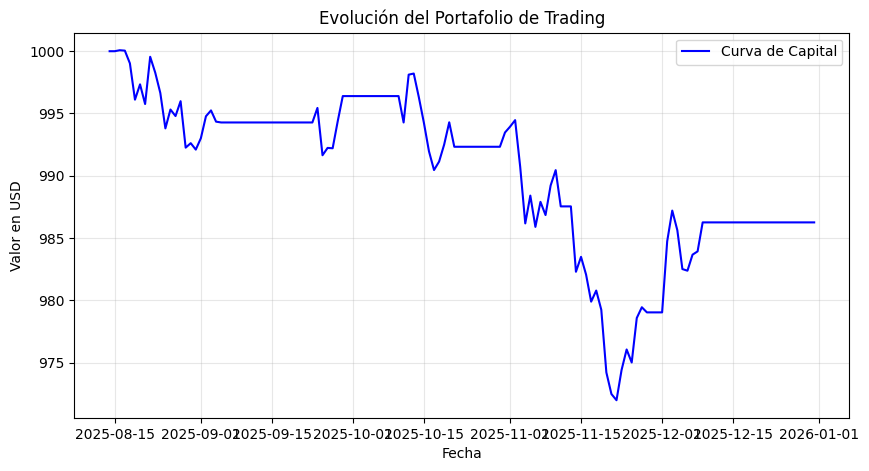

In [15]:
# 5. Ejecutar el Backtest con LightGBM
print("\n--- SIMULACIÓN DE TRADING: LIGHTGBM ---")
df_sim_lgb, trades_lgb = backtest_apex(df_test_completo, y_pred_lgb_ajustado)

Terminó en -1.37% con 11 operaciones cerradas. Fíjate en esa caída libre a mediados de noviembre, seguida de un rebote violentísimo en un par de días (esa V enorme en tu gráfica). LightGBM entró y salió disparado del mercado intentando atrapar la volatilidad extrema.

## Comparativa de los tres modelos
---
| **Modelo** | **Retorno** | **Operaciones** | **Perfil de Trading** | **Diagnóstico** |
| :---: | :---: | :---: | :---: | :---: |
|Random Forest|-1.49%|5|"El Conservador: Lento, exige mucha confirmación."|"Protege el capital en la incertidumbre, pero reacciona tarde a los rebotes rápidos."|
|XGBoost|-1.14%|7|El Equilibrado (Ganador actual): Sigue tendencias claras.|Logró el mejor pico de ganancias en octubre. Tiene el mejor balance entre audacia y precaución|
|LightGBM|-1.37%|11|El Hiperactivo: Sensible al ruido de corto plazo.|"Detecta muchísimos movimientos, pero lo destrozan los ""serruchos"" (falsos rompimientos)."|
